In [2]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
K = 3
limiar_sim_util = 0.01

In [4]:
# Relação entre produtos e usuários
score_produto_usuario = pd.read_csv('../datasets/matriz_produto_usuario.csv')

#Relação entre produtos e produtos
df_similaridade = pd.read_csv(
    '../dados_sinteticos/dados_tratatos/similaridade_item_item.csv',
    index_col=0 
)

In [5]:
score_produto_usuario

,id_produto,U_0,U_1,U_10,U_100,U_101,U_102,U_103,U_104,U_105,...,U_99,U_990,U_991,U_992,U_993,U_994,U_995,U_997,U_998,U_999
0,P_0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
1,P_1,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
2,P_10,0.0,0.00000,0.0,0.0,0.0,0.0,6.331518,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
3,P_11,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
4,P_12,0.0,2.42357,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,P_95,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,1.994154,0.0,...,0.000000,0.0,0.0,0.0,0.0,3.245922,0.0,0.000000,0.0,0.0
96,P_96,0.0,0.00000,0.0,1.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
97,P_97,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,2.385233,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1.556020,0.0,0.0
98,P_98,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,2.762232,0.0,0.0,0.0,0.0,0.000000,0.0,7.914848,0.0,0.0


In [6]:
df_similaridade

,P_0,P_1,P_10,P_11,P_12,P_13,P_14,P_15,P_16,P_17,...,P_90,P_91,P_92,P_93,P_94,P_95,P_96,P_97,P_98,P_99
P_0,1.000000,0.000000,0.044277,0.170036,0.013053,0.000000,0.000000,0.000000,0.051897,0.062071,...,0.000000,0.000000,0.010633,0.0,0.000000,0.000000,0.149624,0.000000,0.038132,0.005890
P_1,0.000000,1.000000,0.000000,0.000000,0.096727,0.000000,0.009647,0.039448,0.000000,0.000000,...,0.000000,0.084355,0.000000,0.0,0.050323,0.019188,0.015019,0.086442,0.101429,0.082315
P_10,0.044277,0.000000,1.000000,0.044079,0.095343,0.000000,0.000000,0.000000,0.000000,0.020372,...,0.027444,0.000000,0.074826,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P_11,0.170036,0.000000,0.044079,1.000000,0.000000,0.000000,0.000000,0.000000,0.050261,0.036552,...,0.066543,0.000000,0.051615,0.0,0.000000,0.000000,0.016058,0.000000,0.000000,0.000000
P_12,0.013053,0.096727,0.095343,0.000000,1.000000,0.024804,0.000000,0.000000,0.000000,0.015453,...,0.000000,0.000000,0.084138,0.0,0.000000,0.085973,0.005064,0.000000,0.076714,0.006874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P_95,0.000000,0.019188,0.000000,0.000000,0.085973,0.000000,0.000000,0.033964,0.000000,0.000000,...,0.000000,0.130265,0.000000,0.0,0.000000,1.000000,0.000000,0.024046,0.039570,0.000000
P_96,0.149624,0.015019,0.000000,0.016058,0.005064,0.100628,0.006149,0.005047,0.095299,0.003110,...,0.000000,0.000000,0.000000,0.0,0.093825,0.000000,1.000000,0.013080,0.048807,0.080525
P_97,0.000000,0.086442,0.000000,0.000000,0.000000,0.043420,0.020932,0.028305,0.015812,0.000000,...,0.000000,0.090141,0.000000,0.0,0.081116,0.024046,0.013080,1.000000,0.019905,0.019464
P_98,0.038132,0.101429,0.000000,0.000000,0.076714,0.177726,0.000000,0.000000,0.045002,0.000000,...,0.000000,0.000000,0.000000,0.0,0.132800,0.039570,0.048807,0.019905,1.000000,0.150915


# Avaliação dos Scores

In [7]:
# Versão estendida da célula abaixo

count_zeros = pd.DataFrame()
matriz_booleana = (df_similaridade == 0) # Uma matriz com valores booleanos
coluna_soma = matriz_booleana.sum(axis=1) # axis=1 preserva o número de linhas e soma as colunas, retornando um vetor
coluna_razao = coluna_soma/len(df_similaridade.columns) # Divide o número de zeros nas colunas pelo número de colunas, em cada linha
count_zeros['count_zeros'] = coluna_razao # atribui como coluna no dataframe de contagens de zeros

In [8]:
# Quantos scores 0 têm cada produto
count_zeros = pd.DataFrame()
count_zeros['count_zeros'] = (df_similaridade == 0).sum(axis=1)/len(df_similaridade.columns)
count_zeros

,count_zeros
P_0,0.64
P_1,0.36
P_10,0.71
P_11,0.65
P_12,0.40
...,...
P_95,0.50
P_96,0.34
P_97,0.32
P_98,0.33


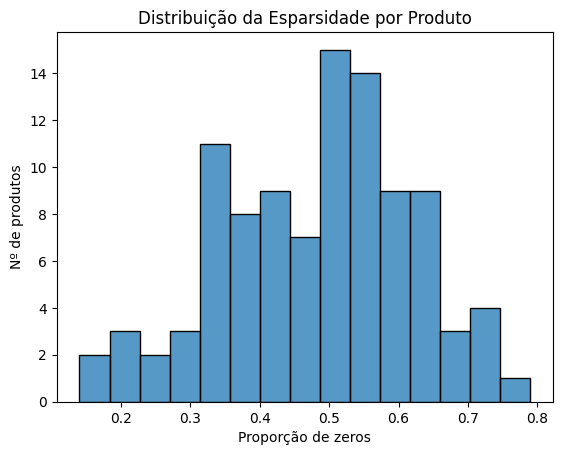

In [9]:
sns.histplot(data=count_zeros, x='count_zeros', bins=15)

plt.xlabel('Proporção de zeros')
plt.ylabel('Nº de produtos')
plt.title('Distribuição da Esparsidade por Produto')

plt.show()

In [10]:
# Remove a coluna de id_produto e extrai os valores como array numpy
X = score_produto_usuario.drop(columns='id_produto').to_numpy(dtype=float)


In [11]:
# Tamanho do array
n_produtos, n_usuarios = X.shape

print(f"Dimensões: {n_produtos} produtos × {n_usuarios} usuários")
print(f"Total de células: {n_produtos * n_usuarios}")

Dimensões: 100 produtos × 977 usuários
Total de células: 97700


In [12]:
# Número de zeros na matriz
zeros = (X == 0).sum()

# Número de não zeros
nao_zeros = (X != 0).sum()

# Esparcidade é o percentual de zeros na matriz
esparsidade = zeros / (n_produtos * n_usuarios)

print(f"Células com valor zero: {zeros} ({esparsidade:.1%})")
print(f"Células com valor > 0: {nao_zeros} ({1 - esparsidade:.1%})")

Células com valor zero: 93374 (95.6%)
Células com valor > 0: 4326 (4.4%)


In [13]:
print("Estatísticas dos scores (somente valores > 0):")

# Vetor contendo apenas os valores diferentes de zero para eststística descritiva agregada.
scores_nao_zero = X[X != 0]
print(pd.Series(scores_nao_zero).describe(percentiles=[0.25, 0.5, 0.75]).round(4))

Estatísticas dos scores (somente valores > 0):
count    4326.0000
mean        3.4984
std         3.0605
min         1.0000
25%         1.5538
50%         2.3795
75%         4.3878
max        29.9831
dtype: float64


In [14]:
# Para cada linha (produto), conta quantas colunas (usuários) têm score diferente de zero
# Também é um vetor, mas com um número por produto
compradores_por_produto = (X != 0).sum(axis=1)

print("Número de usuários que compraram o produto:")
print(pd.Series(compradores_por_produto).describe(percentiles=[0.25, 0.5, 0.75]).round(2))

Número de usuários que compraram o produto:
count    100.00
mean      43.26
std       18.94
min       14.00
25%       31.00
50%       41.00
75%       52.00
max      106.00
dtype: float64


In [15]:
# Similar ao anterior, mas somando as linhas para que o vetor entregue um número por coluna
produtos_por_usuario = (X != 0).sum(axis=0)

print("Número de produtos comprados pelo usuários")
print(pd.Series(produtos_por_usuario).describe(percentiles=[0.25, 0.5, 0.75]).round(2))

Número de produtos comprados pelo usuários
count    977.00
mean       4.43
std        2.31
min        1.00
25%        3.00
50%        4.00
75%        6.00
max       14.00
dtype: float64


Com KNN item-based e similaridade de cosseno, a concentração de interações por usuário é muito menos problemática do que seria no user-based.

A similaridade de cosseno entre dois produtos depende do padrão de quais usuários compraram ambos — não da quantidade absoluta de compras. Um usuário que comprou 14 produtos contribui com 14 dimensões do vetor de cada produto que comprou, mas o cosseno normaliza pelo comprimento do vetor. O usuário com mais aquisições não domina a direção do vetor, apenas contribui para ela.

O que realmente importa para item-based KNN é a coocorrência: dois produtos precisam ter sido comprados pelo mesmo usuário para que exista sinal de similaridade entre eles. Com média de 4.4 produtos por usuário e 977 usuários, a coocorrência entre pares de produtos é o gargalo — não a concentração por usuário.

In [16]:
# Reservando os ids dos produtos numa isntância e os valores como array numpy com as colunas noutra
ids_produtos = score_produto_usuario['id_produto'].values
X_df = score_produto_usuario.drop(columns='id_produto')
X = X_df.to_numpy(dtype=float)

# Converte a matriz em formado CSR (Compressed Sparse Row) que ignora os valores zero
# Os valores não-zero são agrupados por linhas com ponteiros
X_sparse = csr_matrix(X)

In [17]:
#n_produtos, n_usuarios = X.shape
total_celulas = n_produtos * n_usuarios
qtd_zeros = (X == 0).sum()

# Esparsidade global é a razão de zeros
esparsidade_global = qtd_zeros / total_celulas if total_celulas > 0 else np.nan

In [18]:
# # compradores_por_produto = (X != 0).sum(axis=1)

# #dataframe do número de usuários por produto
# tabela_compradores_produto = pd.DataFrame({
#     'id_produto': ids_produtos,
#     'n_usuarios_compradores': compradores_por_produto
# }).sort_values('id_produto').reset_index(drop=True)

In [19]:
# estatisticas_compradores_produto = pd.Series(compradores_por_produto).describe(percentiles=[0.25, 0.5, 0.75])

In [20]:
# estatisticas_compradores_produto

In [21]:


# resumo_compradores_produto = pd.DataFrame({
#     'minimo': [estatisticas_compradores_produto['min']],
#     'q1': [estatisticas_compradores_produto['25%']],
#     'mediana': [estatisticas_compradores_produto['50%']],
#     'media': [estatisticas_compradores_produto['mean']],
#     'q3': [estatisticas_compradores_produto['75%']],
#     'maximo': [estatisticas_compradores_produto['max']]
# })

In [22]:
# Coocorrência: Quantos usuários comparam os mesmos produtos

# Matriz convertendo qualquer número maior que 0 em 1
matriz_binaria = (X != 0).astype(int)

# Multiplicação matricial
# Resulta em uma matriz quadrada, cujos valores quantos usuários comparam tanto o produto da linha quanto da coluna
cooc_item_item = matriz_binaria @ matriz_binaria.T

# Matriz quadrada com valores False apenas na diagonal principal
mask_fora_diagonal = ~np.eye(n_produtos, dtype=bool)

# Aplicando a máscada acima
# Retorna um vetor com os valores de coocorrência, exceto na diagonal principal:
    # a diagonal principal vai ter 100% de ocorrência e não é informação útil
cooc_sem_diagonal = cooc_item_item[mask_fora_diagonal]

In [23]:
# # Formatação de impressão

# if cooc_sem_diagonal.size > 0:
#     serie_cooc = pd.Series(cooc_sem_diagonal)
#     estatisticas_cooc = serie_cooc.describe(percentiles=[0.25, 0.5, 0.75])
#     resumo_cooc_item_item = pd.DataFrame({
#         'minimo': [estatisticas_cooc['min']],
#         'q1': [estatisticas_cooc['25%']],
#         'mediana': [estatisticas_cooc['50%']],
#         'media': [estatisticas_cooc['mean']],
#         'q3': [estatisticas_cooc['75%']],
#         'maximo': [estatisticas_cooc['max']]
#     })
# else:
#     resumo_cooc_item_item = pd.DataFrame({
#         'minimo': [np.nan],
#         'q1': [np.nan],
#         'mediana': [np.nan],
#         'media': [np.nan],
#         'q3': [np.nan],
#         'maximo': [np.nan]
#     })

In [24]:
# Formatação de impressão

if cooc_sem_diagonal.size > 0:
    serie_cooc = pd.Series(cooc_sem_diagonal)
    print('Estatística descritiva de coocorrências:')
    print(serie_cooc.describe())
else:
    print('Não há valores imprimíveis')

Estatística descritiva de coocorrências:
count    9900.000000
mean        2.025455
std         3.001929
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        24.000000
dtype: float64


In [25]:
# Captando os índices do triângulo superior da matriz simétrica e usando como máscara para selecionar os valores no 
indices_upper = np.triu_indices(n_produtos, k=1)
cooc_upper = cooc_item_item[indices_upper]

# Contagem de quantos pares de produtos têm número de coocorrência acima de cada faixa
pares_cooc_zero = int((cooc_upper == 0).sum())
pares_cooc_menor_5 = int((cooc_upper < 5).sum())
pares_cooc_menor_10 = int((cooc_upper < 10).sum())
pares_cooc_menor_20 = int((cooc_upper < 20).sum())
total_pares_produtos = len(cooc_upper)

In [26]:
# Garantindo que K não será maior que o número de produtos
n_neighbors_ajustado = min(K, n_produtos-1)

# Definição do modelo
modelo_knn = NearestNeighbors(
    n_neighbors=n_neighbors_ajustado, # K
    metric='cosine',
    algorithm='brute'
)

# Ajuste aos dados
# Com a matriz esparsa há economia de memória
modelo_knn.fit(X_sparse)

# Aplica o ajuste aos dados para extrair as distâncias
distancias, indices = modelo_knn.kneighbors(X_sparse)

In [27]:
# Extrai os valores das similaridades para um array numpy
matriz_similaridade = df_similaridade.values

# Recria as variáveis derivadas
similaridade_sem_diagonal = matriz_similaridade.copy()
np.fill_diagonal(similaridade_sem_diagonal, np.nan)
sim_fora_diagonal = similaridade_sem_diagonal[~np.isnan(similaridade_sem_diagonal)]

In [28]:
# O trecho abaixo foi descontinuado pois o optei por usar o modelo do sklearn

# # Converte similaridade em distância (cosseno: distância = 1 - similaridade)
# distancia_item_item = 1 - matriz_similaridade
# np.fill_diagonal(distancia_item_item, np.inf)  # ignora o próprio item

# k = 3
# indices = np.argsort(distancia_item_item, axis=1)[:, :k]
# distancias = np.sort(distancia_item_item, axis=1)[:, :k]

In [29]:
# Formatação de impressão

if sim_fora_diagonal.size > 0:
    serie_sim = pd.Series(sim_fora_diagonal)
    print('Estatística descritiva de coocorrências:')
    print(serie_sim.describe())
else:
    print('Não há valores imprimíveis')

Estatística descritiva de coocorrências:
count    9900.000000
mean        0.034114
std         0.054654
min         0.000000
25%         0.000000
50%         0.003776
75%         0.050057
max         0.428768
dtype: float64


Para cada produto
    armazena o id_produto da vez
    armazena

In [30]:
linhas_vizinhos = []

for i in range(n_produtos):
    id_produto_ref = ids_produtos[i]        # id do produto da vez
    vizinhos_idx = indices[i]               # array com os índices numéricos (não a nomenclatura) dos K vizinhos
    vizinhos_dist = distancias[i]            # array com as distâncias correspondentes a esses vizinhos
    vizinhos_sim = 1 - vizinhos_dist

    pares = []                              # uma lista de pares para cada produto
    for idx_vizinho, sim in zip(vizinhos_idx, vizinhos_sim):    # percorre os índices e a similaridade
        if idx_vizinho != i:                                    # se o índice atual não for o do produto atual
            pares.append((ids_produtos[idx_vizinho], sim))          # adiciona uma tupla com o id do vizinho e a similaridade com ele

    pares = sorted(pares, key=lambda x: x[1], reverse=True)[:K] # Organiza a lista de vizinhos do produto da vez de acordo com a similaridade (segundo item de cada tupla)
                                                                # Corta nos K primeiros vizinhos

    for rank, (id_vizinho, sim) in enumerate(pares, start=1):   # Para cada tupla de vizinhos, enumerados começando do 1
        linhas_vizinhos.append({                                # Adiciona uma linha com
            'id_produto': id_produto_ref,                           # id do produto da vez
            'rank_vizinho': rank,                                   # ranking do produto vizinho na lista do produto da vez
            'id_produto_vizinho': id_vizinho,                       # id do produto vizinho
            'similaridade': sim                                     # similaridade entre eles
        })

tabela_K_vizinhos = pd.DataFrame(linhas_vizinhos)

In [31]:
# Criação de uma tabela com produtos sem vizinhos cuja similaridade é maior que o limiar

if tabela_K_vizinhos.empty:
    produtos_sem_vizinhos_uteis = pd.DataFrame({
        'id_produto': ids_produtos,
        'motivo': 'sem vizinhos calculados'
    })
else:
    # 
    max_sim_por_produto = (
        tabela_K_vizinhos.groupby('id_produto', as_index=False)['similaridade'] # Agrupa a tabela por produto, mantendo 'id_produto' como coluna
        .max()                                                                  # o agrupamento é feito pela maior similaridade de cada id_produto
        .rename(columns={'similaridade': 'max_similaridade_vizinho'})           # renomeia a coluna de similaridade para 'max_similaridade_vizinho'
    )

    # merge (left join) para incluir produtos que não aparecem na tabela_K_vizinhos
    produtos_sem_vizinhos_uteis = pd.DataFrame({'id_produto': ids_produtos}).merge(
        max_sim_por_produto,
        on='id_produto',
        how='left'
    )
    
    # ausentes recebem NaN e são substituídos por 0
    produtos_sem_vizinhos_uteis['max_similaridade_vizinho'] = produtos_sem_vizinhos_uteis['max_similaridade_vizinho'].fillna(0)
    
    # Filtra as similaridade para que seja aproveitada apenas as superiores ao limiar
    produtos_sem_vizinhos_uteis = produtos_sem_vizinhos_uteis[
        produtos_sem_vizinhos_uteis['max_similaridade_vizinho'] <= limiar_sim_util
    ].copy()

    
    produtos_sem_vizinhos_uteis['motivo'] = 'todas as similaridades sao zero ou muito proximas de zero'

In [32]:
produtos_sem_vizinhos_uteis

,id_produto,max_similaridade_vizinho,motivo


In [33]:
proporcao_produtos_ate_2_compradores = (compradores_por_produto <= 2).mean() if n_produtos > 0 else np.nan
proporcao_pares_cooc_zero = (cooc_upper == 0).mean() if total_pares_produtos > 0 else np.nan
proporcao_pares_cooc_menor_5 = (cooc_upper < 5).mean() if total_pares_produtos > 0 else np.nan
proporcao_sim_baixa = (sim_fora_diagonal <= 0.01).mean() if sim_fora_diagonal.size > 0 else np.nan
proporcao_produtos_com_vizinho_util = 1 - (len(produtos_sem_vizinhos_uteis) / n_produtos) if n_produtos > 0 else np.nan

In [34]:
diagnosticos = []

if not np.isnan(proporcao_produtos_ate_2_compradores) and proporcao_produtos_ate_2_compradores >= 0.5:
    diagnosticos.append('Baixa robustez: a maioria dos produtos tem poucos usuarios compradores.')

if not np.isnan(proporcao_pares_cooc_zero) and proporcao_pares_cooc_zero >= 0.5:
    diagnosticos.append('Coocorrencia fraca: muitos pares de produtos nunca aparecem juntos.')

if not np.isnan(proporcao_pares_cooc_menor_5) and proporcao_pares_cooc_menor_5 >= 0.8:
    diagnosticos.append('Coocorrencia limitada: a maior parte dos pares tem menos de 5 usuarios em comum.')

if not np.isnan(proporcao_sim_baixa) and proporcao_sim_baixa >= 0.8:
    diagnosticos.append('Baixo poder discriminativo: as similaridades entre itens sao quase sempre proximas de zero.')

if (
    not np.isnan(proporcao_produtos_ate_2_compradores) and
    not np.isnan(proporcao_pares_cooc_zero) and
    not np.isnan(proporcao_sim_baixa) and
    not np.isnan(proporcao_produtos_com_vizinho_util) and
    proporcao_produtos_ate_2_compradores < 0.5 and
    proporcao_pares_cooc_zero < 0.5 and
    proporcao_sim_baixa < 0.8 and
    proporcao_produtos_com_vizinho_util >= 0.7
):
    diagnosticos.append('A abordagem parece viavel: ha cobertura razoavel por produto e vizinhos com similaridade positiva.')

if len(diagnosticos) == 0:
    diagnosticos.append('Diagnostico intermediario: a matriz pode ser utilizavel, mas a qualidade da vizinhanca item-item depende de ajustes de filtro e volume de interacoes.')

diagnostico_final = ' '.join(diagnosticos)

In [35]:
print('\nPares com coocorrencia zero:', pares_cooc_zero)
print('Pares com coocorrencia < 5:', pares_cooc_menor_5)
print('Pares com coocorrencia < 10:', pares_cooc_menor_10)
print('Pares com coocorrencia < 20:', pares_cooc_menor_20)
print('\nDiagnostico final:')
print(diagnostico_final)



Pares com coocorrencia zero: 2403
Pares com coocorrencia < 5: 4132
Pares com coocorrencia < 10: 4772
Pares com coocorrencia < 20: 4948

Diagnostico final:
Coocorrencia limitada: a maior parte dos pares tem menos de 5 usuarios em comum. A abordagem parece viavel: ha cobertura razoavel por produto e vizinhos com similaridade positiva.


Nenhum produto isolado — todos têm pelo menos 14 compradores  
  
Mediana de coocorrência = 1 significa que a maioria dos pares tem pelo menos algum sinal  
  
Similaridade máxima de 0.43 indica que existem pares genuinamente similares — o modelo tem o que aprender  
  
O que é desafiador mas esperado: 2.403 pares com coocorrência zero (de 4.950 pares totais) — quase metade sem sinal direto  
  
Média de similaridade de 0.034 é baixa, mas típica de matrizes esparsas em item-based CF  
  
A interpretação prática:
O KNN vai conseguir encontrar vizinhos para a maioria dos produtos, mas com poucos vizinhos confiáveis — o K ideal provavelmente será pequeno (3 a 5). Com K grande, o modelo vai incluir vizinhos com similaridade próxima de zero, degradando as recomendações.

In [36]:
#Dependendo de como o sistema é construído, ângulos maiores que 90° resultariam em similaridade negativa
# Entretanto, como todos os scores de produtos variam entre 0 e 1, essa possibilidade não exsites
# Caso o cálculo de scores preciseser alterado de alguma forma, este trecho pode ser útil
vizinhos_positivos = (df_similaridade > 0).sum(axis=1) - 1
print(vizinhos_positivos.describe())

count    100.000000
mean      50.940000
std       13.864292
min       20.000000
25%       41.000000
50%       49.000000
75%       62.250000
max       85.000000
dtype: float64
